In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import numpy as np
import maptools
import os

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from multiprocessing import Pool
import pickle
import h5py
from datetime import datetime

maptools.job.info()
maptools.plot.dark()
!which python

import time
import numba
import ImageD11.columnfile
import ImageD11.sinograms.dataset
import ImageD11.sinograms.geometry as geometry
import ImageD11.sinograms.point_by_point
import ImageD11.sinograms.point_by_point as pbp
from ImageD11.nbGui import nb_utils as utils

AttributeError: module 'maptools' has no attribute 'job'

In [3]:
h5path = os.path.join( maptools.paths.PROCESS, 'al1050_15pct_center_slice/medium_pks.h5' )
parpath = os.path.join( maptools.paths.PROCESS, 'al1050_15pct_center_slice/al1050.par' )
colf = maptools.io.read_peaks(h5path, parpath)
colf.updateGeometry()
print(f"Original number of peaks in columnfile is : {np.round(colf.nrows / 1e6).astype(int)} Million")

Original number of peaks in columnfile is : 151 Million


In [3]:
np.random.seed(1)
original_number_of_peaks = colf.nrows
fraction_to_keep = 0.12
number_of_peaks_to_keep = int(np.round(colf.nrows*fraction_to_keep))
sample = np.random.permutation(colf.nrows)[:number_of_peaks_to_keep]
mask = np.zeros( (colf.nrows, ), dtype=bool )
mask[sample] = True
colf.filter(mask)
print(f"Keeping {fraction_to_keep*100} % of the peaks")
print(f"Number of peaks in after downsampling is : {np.round(colf.nrows / 1e6).astype(int)} Million")

Keeping 12.0 % of the peaks
Number of peaks in after downsampling is : 18 Million


In [4]:
timetag = datetime.now().strftime("%Y_%m%d_%H%M%S")
savepath = os.path.join( maptools.paths.PROCESS, 'al1050_15pct_center_slice' )
savefile = h5path.split('.')[0] + '_' + str( int( np.round(number_of_peaks_to_keep/1e6) ) ) + 'M_' + timetag
savepath, savefile

('/data/visitors/danmax/20251117/2025110808/process/al1050_15pct_center_slice',
 '/data/visitors/danmax/20251117/2025110808/process/al1050_15pct_center_slice/medium_pks_18M_2025_1213_095603')

In [ ]:
ystep = maptools.constants.DTYSTEP
ymin  = maptools.constants.DTYMIN
ymax  = maptools.constants.DTYMAX
ypositions = maptools.constants.DTYPOSITIONS
ny = maptools.constants.NUMBER_OF_DTY_STEPS
nomega = maptools.constants.NUMBER_OF_OMEGA_STEPS_IN_360_RANGE
y0 = maptools.constants.ROTATION_AXIS_DTY_SHIFT

dtyr = np.round(colf.dty, maptools.constants.DTYPRECISION)
colf.dty[:] = dtyr[:]
dtyi = geometry.dty_to_dtyi(colf.dty, ystep, ymin).astype(np.uint32)
colf.addcolumn(dtyi, "dtyi")

colf.addcolumn(np.cos(np.radians(colf.omega)), "cosomega")
colf.addcolumn(np.sin(np.radians(colf.omega)), "sinomega")

In [6]:
t1 = time.perf_counter()
xi0, yi0 = 0, 0  # these are sample space coordinates
idx, ydist = pbp.get_voxel_idx(
    y0, xi0, yi0, colf.sinomega, colf.cosomega, colf.dty, ystep
)
t2 = time.perf_counter()
print(t2 - t1)

0.1265044752508402


In [7]:
@numba.njit(parallel=True)
def get_frac(sinomega, cosomega, dty, ystep, ny, ypositions, nrows):
    frac = np.zeros((ny, ny))
    for i in numba.prange(len(ypositions)):
        xi0 = ypositions[i]
        for j in range(len(ypositions)):
            yi0 = ypositions[j]
            idx, _ = pbp.get_voxel_idx(
                y0,
                xi0,
                yi0,
                sinomega,
                cosomega,
                dty,
                ystep,
            )
            frac[i, j] = len(idx) / float(nrows)
    return frac
frac = get_frac(colf.sinomega, colf.cosomega, colf.dty, ystep, ny, ypositions, colf.nrows)

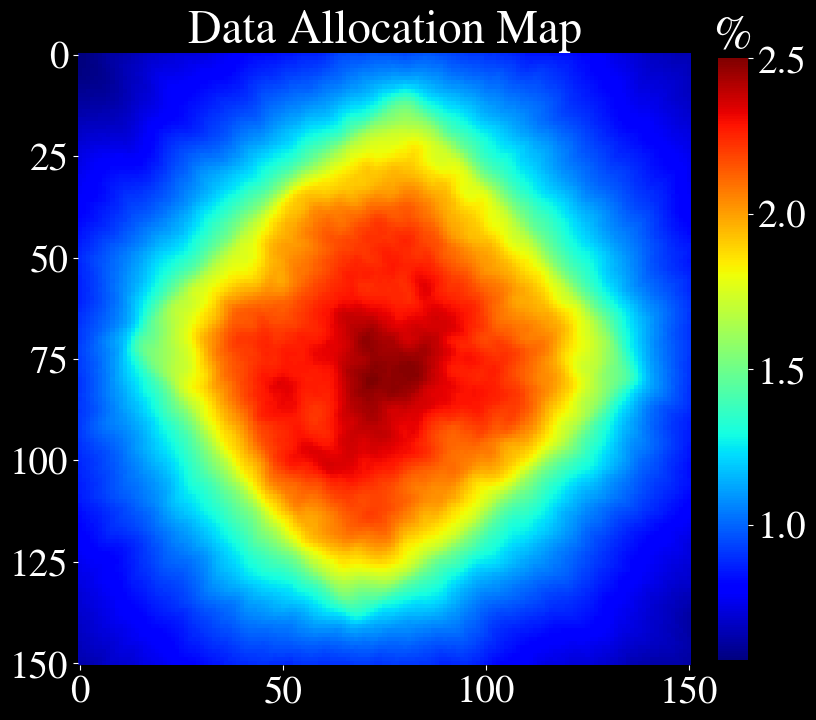

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(9, 9))
im = ax.imshow(100 * frac, cmap="jet")
cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.04)
cbar.ax.set_title("%")
for axi in [ax, cbar.ax]:
    for spine in axi.spines.values():
        spine.set_visible(False)
ax.set_title("Data Allocation Map")
plt.tight_layout()
plt.show()

In [10]:
ucell = maptools.constants.UNITCELL
ucell.makerings(colf.ds.max())

In [11]:
dset = maptools.dummy.dset(colf.copy(), parpath, h5path, savefile, ny, nomega)
dset.save()

In [12]:
assert dset.ymin == ymin
assert dset.ymax == ypositions[-1]
assert np.allclose(dset.ystep, ystep)
assert np.allclose(dset.ostep, 0.11996)
assert dset.omin == colf.omega.min()

In [17]:
fraction_of_strongest_peaks_to_use = 0.25 # we do not need all peaks to generate the inital trial orientations we use only the strongest part of the peakset
hkl_tol = 0.05 # only peaks that bit within this tolerance in reciprocal space to an integer h,k,l point are considered assigned to grain
ds_tol = 0.01 # Deviation from predicted theoretical ring value beyond which the peak is discared. In units of inverse angstrom i.e (1 / d)-tolerance where d is the lattice d-spacing
eta_wedge_in_degrees = 6 # Peaks close to eta=0 and eta=180 stay in diffraction all the time in omega, these are not good peaks to use.
maximum_number_of_grains_per_point = 40 # this many candidate grains are assigned per voxel in the sample
fraction_of_peaks_to_assign_grain = 0.6 # the trial grain needs at least this fraction of the theoretical number of peaks to be scored

maxint = np.percentile(colf.sum_intensity, 100 - fraction_of_strongest_peaks_to_use*100)
ifrac = maxint / colf.sum_intensity.max()
etacut = np.sin(np.radians(np.abs(eta_wedge_in_degrees)))

In [18]:

pbpmanager = pbp.PBP(
    dset.parfile,
    dset,
    hkl_tol=hkl_tol,
    fpks=fraction_of_peaks_to_assign_grain,
    ds_tol=ds_tol,
    etacut=etacut,
    ifrac=ifrac,
    gmax=maximum_number_of_grains_per_point,
    cosine_tol=2 * np.cos(np.radians(90 - dset.ostep * 1.5)),
    y0=y0,
    symmetry="cubic",
    foridx=[0, 1, 2, 3, 4, 5, 6],
    forgen=[0, 1, 2],
    uniqcut=0.7,
)


In [21]:
cf = colf.copy()
ImageD11.columnfile.colfileobj_to_hdf( cf, savefile + '_colf.h5' )
pbpmanager.setpeaks(cf)

0 0.4272 (1, 1, 1) 8 724553 used, sum_intensity> 598.0
1 0.4933 (0, 2, 0) 6 518510 used, sum_intensity> 434.6571340292222
2 0.6977 (2, 0, 2) 12 1454959 used, sum_intensity> 192.966761058677
3 0.8181 (3, 1, 1) 24 3300100 used, sum_intensity> 122.57762813795037
4 0.8545 (2, 2, 2) 8 1079616 used, sum_intensity> 108.11045457875575
5 0.9867 (0, 0, 4) 6 776705 used, sum_intensity> 49.98841813218491
6 1.0752 (3, 3, 1) 24 2237021 used, sum_intensity> 85.35537158492573
7 1.1031 (4, 2, 0) 24 skipped
8 1.2084 (4, 2, 2) 24 skipped
9 1.2817 (1, 5, 1) 32 skipped
10 1.3954 (4, 0, 4) 12 skipped
11 1.4593 (5, 1, 3) 48 skipped
12 1.4800 (2, 4, 4) 30 skipped
13 1.5601 (6, 2, 0) 24 skipped
14 1.6175 (3, 5, 3) 24 skipped
15 1.6362 (6, 2, 2) 24 skipped
16 1.7090 (4, 4, 4) 8 skipped
17 1.7616 (1, 1, 7) 48 skipped
18 1.7788 (4, 6, 0) 24 skipped
19 1.8459 (4, 2, 6) 48 skipped
Using for indexing: 9375250 npks, minpks, forgen 88 52 [0, 1, 2]


In [ ]:
#ImageD11.cImageD11.cimaged11_omp_set_num_threads(1)
grains_filename = savefile + "_pbpmap.h5"
if os.path.isfile(grains_filename):
    os.remove(grains_filename)
pbpmanager.point_by_point(grains_filename, loglevel=3, gridstep=1, nprocs=44)
print("Exit main thread", time.ctime())

{'cosine_tol': 0.006281080586989038,
 'ds_tol': 0.01,
 'forgen': [0, 1, 2],
 'hkl_tol': 0.05,
 'hmax': 4,
 'minpks': 52,
 'uniqcut': 0.7,
 'y0': -0.03243855634667874,
 'ymin': -0.75,
 'ystep': 0.01}
Done   0.522 %, average grains/point  29.33, 0.543 /s/point, total 71.7 /s

In [ ]:
pbpmap = pbp.PBPMap(grains_filename)
pbpmap.plot_nuniq_hist()

In [ ]:
pbpmap.choose_best(minpeaks=30)
pbpmap.plot_best(minpeaks=30)

In [ ]:
grains = []
for ubi in pbpmap.best_ubi.reshape(-1, 3, 3):
    if not np.isnan(ubi).any():
        g = ImageD11.grain.grain(ubi)
        g.ref_unitcell = ucell
        grains.append(g)

m = ~np.isnan(pbpmap.best_ubi[:, :, 0, 0])
from ImageD11.nbGui import nb_utils as utils

utils.get_rgbs_for_grains(grains)
gmap = np.empty(m.shape, dtype=object)
gmap[m] = grains

In [ ]:
ubimap = pbpmap.best_ubi
rgbmap = np.zeros((*m.shape, 3))
for i in range(ubimap.shape[0]):
    for j in range(ubimap.shape[1]):
        if ~np.isnan(ubimap[i, j]).any():
            rgbmap[i, j] = gmap[i, j].rgb_z

In [ ]:
plt.style.use("dark_background")
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
from scipy.ndimage import gaussian_filter
s = pbpmap.best_nuniq[:,:,None].astype(float)
s = gaussian_filter(s, 1)
s /= s.max()
s[s<0.6] = 0
s[s>0] = 1
for spine in ax.spines.values():
    spine.set_visible(False)
im = ax.imshow((rgbmap*s)[10:-10,10:-10])
plt.tight_layout()
plt.show()

In [ ]:
for g in grains:
    g.ref_unitcell = ucell
plt.style.use("dark_background")
utils.plot_all_ipfs(grains, s=0.5)
plt.show()

In [ ]:
filetag = grains_filename[-40:-10]
filetag